# Fase 3, Paso 4 — DCA con señal de timing

Ajuste a un escenario de inversión más realista para alguien que empieza de cero: sin capital inicial grande, aportando ~200-300 MXN al mes (~$10-15 USD, se usa $12 USD/mes como cifra representativa). Eso descarta Buy & Hold puro (asume capital ya disponible) y apunta directo a **DCA**, que ya se validó en el Paso 1 con buenos resultados frente a Buy & Hold.

La pregunta de esta libreta: **¿mejora el DCA si, en vez de invertir cada aportación automáticamente, se usa una señal de timing (SMA, Momentum, RSI del Paso 2) para decidir si esa aportación se invierte o se guarda en efectivo hasta que la señal sea favorable?**

**Por qué se reusan las señales del Paso 2 y no el modelo de ML del Paso 3:** el ML ya quedó último de cinco estrategias en el holdout (Paso 3) — no hay razón para esperar que mejore solo por cambiar el mecanismo de entrada de capital, y probarlo aquí requeriría apartar un holdout nuevo sin haber cambiado nada de fondo en el modelo. Las reglas de SMA/Momentum/RSI, en cambio, son parámetros fijos (no ajustados a los datos) — reusarlas en un mecanismo de aportación distinto no reabre ningún riesgo de p-hacking, igual que no lo reabrió comparar Buy & Hold vs. DCA en el Paso 1 con la misma regla.

**Corrección tras auditoría del proyecto:** esta libreta originalmente usaba 5 bps de costo por operación (supuesto inicial de bajo costo). Como el bróker finalmente elegido fue GBM+ (~0.25% = 25 bps en ETFs de EE.UU.), corregí `COSTO_BPS` a 25 en toda esta libreta. La conclusión no cambia (SMA sigue ganando a DCA simple), pero los números sí — estos ya son los correctos.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from inversion import strategies, backtest, viz

APORTE_MENSUAL = 12.0  # USD/mes (~200-300 MXN)
APORTE_SEMANAL = APORTE_MENSUAL * 12 / 52  # mismo presupuesto total, repartido más fino
COSTO_BPS = 25.0  # GBM+ real en ETFs de EE.UU. (no 5 bps de IBKR — bróker que finalmente NO se eligió)
FECHA_INICIO_ANALISIS = "2000-01-01"

df = pd.read_csv("../data/processed/spy_diario.csv", parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

## Mecánica del DCA con timing

Cada mes (o semana) se aparta la aportación en una reserva en efectivo (0% de rendimiento, mismo criterio que en el Paso 2). Si la señal del día anterior dice "invertido", se compra con **toda la reserva acumulada** — no solo la aportación de ese periodo, para no dejar dinero ocioso indefinidamente una vez que la señal vuelve a ser favorable. Es la interpretación más natural de "aporta cada mes, pero solo compra cuando conviene": el dinero nunca deja de aportarse, solo espera en efectivo el momento de entrar.

Implementado en `backtest.simular_dca` — motor nuevo (el de Paso 1-3, `backtest.simular`, asume capital ya disponible de una sola vez, no aportaciones periódicas). La métrica de rendimiento es **IRR** (rendimiento ponderado por dinero), no CAGR — mismo criterio que el benchmark de DCA del Paso 1, porque el capital entra en momentos distintos.

## Comparación mensual: DCA simple vs. DCA + timing

In [2]:
señales = {
    "DCA simple": strategies.señal_buy_and_hold,
    "DCA + SMA 50/200": strategies.señal_sma,
    "DCA + Momentum 12m": strategies.señal_momentum,
    "DCA + RSI(14) 30/70": strategies.señal_rsi,
}


def correr_dca(frecuencia, aporte, periodos_por_año):
    filas, series = [], {}
    for nombre, señal_fn in señales.items():
        señal = señal_fn(df)
        recortado = backtest.recortar_periodo(df, señal, FECHA_INICIO_ANALISIS)
        simulado, flujos = backtest.simular_dca(recortado, aporte, frecuencia, COSTO_BPS)
        filas.append(backtest.resumen_dca(simulado, flujos, aporte, nombre, periodos_por_año))
        series[nombre] = simulado[["fecha", "valor"]]
    return pd.DataFrame(filas), series


resumen_mensual, series_mensual = correr_dca("ME", APORTE_MENSUAL, 12)
resumen_mensual

,Escenario,Total aportado (USD),Valor final (USD),IRR anualizado,Drawdown máximo,Sharpe (rf=0),Sortino (rf=0),Operaciones,% tiempo invertido
0,DCA simple,3852.0,23449.138261,0.116381,-0.475274,0.518607,0.660720,1,0.999851
1,DCA + SMA 50/200,3852.0,23660.553865,0.116905,-0.432407,0.552751,0.704438,27,0.738290
2,DCA + Momentum 12m,3852.0,23074.267807,0.115439,-0.437460,0.529763,0.674826,91,0.778885
3,DCA + RSI(14) 30/70,3852.0,23334.412057,0.116094,-0.476410,0.538979,0.668258,46,0.364907


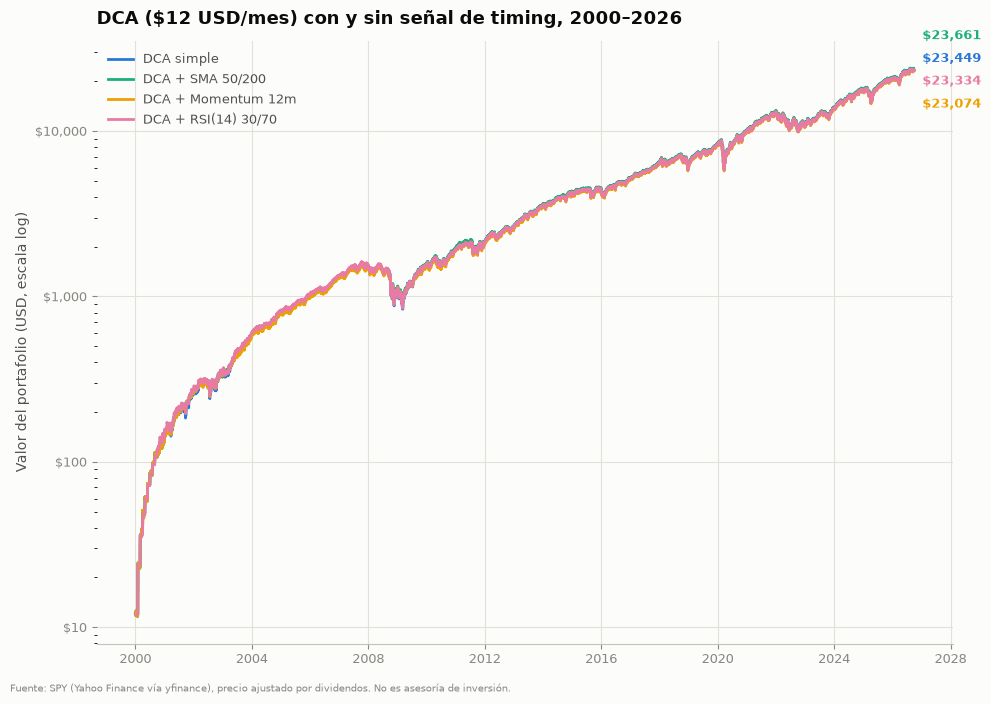

In [3]:
colores = {
    "DCA simple": viz.COLOR_BUY_AND_HOLD,
    "DCA + SMA 50/200": viz.COLOR_SMA,
    "DCA + Momentum 12m": viz.COLOR_MOMENTUM,
    "DCA + RSI(14) 30/70": viz.COLOR_RSI,
}

serie_consolidada = None
for nombre, s in series_mensual.items():
    columna = s.rename(columns={"valor": nombre})
    serie_consolidada = columna if serie_consolidada is None else serie_consolidada.merge(columna, on="fecha")

viz.graficar_todas_las_estrategias(
    serie_consolidada,
    series=[(nombre, colores[nombre], nombre) for nombre in señales],
    titulo=f"DCA (${APORTE_MENSUAL:.0f} USD/mes) con y sin señal de timing, 2000–2026",
    archivo_salida="../outputs/figures/dca_con_timing_mensual.png",
)

## ¿Mejora si se aporta semanal en vez de mensual?

Mismo presupuesto total (se reparte el aporte mensual entre ~4.33 semanas), solo cambia la granularidad de las aportaciones — para aislar el efecto de la frecuencia del efecto de tener más o menos dinero invertido.

In [4]:
resumen_semanal, series_semanal = correr_dca("W", APORTE_SEMANAL, 52)

comparacion_frecuencia = resumen_mensual[["Escenario", "IRR anualizado", "Drawdown máximo", "Sharpe (rf=0)"]].merge(
    resumen_semanal[["Escenario", "IRR anualizado", "Drawdown máximo", "Sharpe (rf=0)"]],
    on="Escenario", suffixes=(" (mensual)", " (semanal)"),
)
comparacion_frecuencia

,Escenario,IRR anualizado (mensual),Drawdown máximo (mensual),Sharpe (rf=0) (mensual),IRR anualizado (semanal),Drawdown máximo (semanal),Sharpe (rf=0) (semanal)
0,DCA simple,0.116381,-0.475274,0.518607,0.115724,-0.474778,0.518607
1,DCA + SMA 50/200,0.116905,-0.432407,0.552751,0.116184,-0.433995,0.554579
2,DCA + Momentum 12m,0.115439,-0.437460,0.529763,0.114675,-0.439017,0.527326
3,DCA + RSI(14) 30/70,0.116094,-0.476410,0.538979,0.115423,-0.475737,0.538218


## ¿Y si la señal también vende, no solo controla las aportaciones nuevas?

**Corrección importante sobre lo hecho arriba:** las combinaciones "DCA + timing" de las secciones anteriores solo deciden si el dinero *nuevo* entra o espera en efectivo — las unidades ya compradas nunca se venden, aunque la señal vuelva a apagarse después. Es distinto de las reglas del Paso 2/3, donde la señal sí protegía el capital ya invertido (vender = dejar de captar el retorno del mercado ese tramo).

Esta sección prueba la versión **simétrica**: cuando la señal baja a 0, se vende TODO lo que ya estaba invertido (no solo se detienen las aportaciones nuevas), y se vuelve a comprar todo cuando la señal regresa a 1 — mismo criterio que `backtest.simular` del Paso 2/3, ahora aplicado a un portafolio que crece con aportaciones periódicas (`vender_en_señal_negativa=True` en `backtest.simular_dca`).

In [5]:
def correr_dca_variante(vender_en_señal_negativa):
    filas = []
    for nombre, señal_fn in señales.items():
        señal = señal_fn(df)
        recortado = backtest.recortar_periodo(df, señal, FECHA_INICIO_ANALISIS)
        simulado, flujos = backtest.simular_dca(
            recortado, APORTE_MENSUAL, "ME", COSTO_BPS,
            vender_en_señal_negativa=vender_en_señal_negativa,
        )
        filas.append(backtest.resumen_dca(simulado, flujos, APORTE_MENSUAL, nombre, 12))
    return pd.DataFrame(filas)


solo_compra = correr_dca_variante(False).set_index("Escenario")
compra_y_venta = correr_dca_variante(True).set_index("Escenario")

comparacion_venta = pd.concat({
    "Solo controla dinero nuevo": solo_compra[["Valor final (USD)", "IRR anualizado", "Drawdown máximo", "Sharpe (rf=0)"]],
    "También vende lo ya invertido": compra_y_venta[["Valor final (USD)", "IRR anualizado", "Drawdown máximo", "Sharpe (rf=0)"]],
}, axis=1)
comparacion_venta

Solo controla dinero nuevo                                 \
                             Valor final (USD) IRR anualizado Drawdown máximo   
Escenario                                                                       
DCA simple                        23449.138261       0.116381       -0.475274   
DCA + SMA 50/200                  23660.553865       0.116905       -0.432407   
DCA + Momentum 12m                23074.267807       0.115439       -0.437460   
DCA + RSI(14) 30/70               23334.412057       0.116094       -0.476410   

                                  También vende lo ya invertido  \
                    Sharpe (rf=0)             Valor final (USD)   
Escenario                                                         
DCA simple               0.518607                  23449.138261   
DCA + SMA 50/200         0.552751                  14224.410942   
DCA + Momentum 12m       0.529763                  13805.437787   
DCA + RSI(14) 30/70      0.538979                   9023.322198   

                                                                  
                    IRR anualizado Drawdown máximo Sharpe (rf=0)  
Escenario                                                         
DCA simple                0.116381       -0.475274      0.518607  
DCA + SMA 50/200          0.086671       -0.335993      0.644812  
DCA + Momentum 12m        0.084856       -0.268518      0.634244  
DCA + RSI(14) 30/70       0.058411       -0.464880      0.344271

## Lectura

*(Actualizado con el costo real de GBM+, 25 bps, tras la auditoría del proyecto — ver nota al inicio de esta libreta.)*

**¿Ayuda la señal de timing al DCA (controlando solo el dinero nuevo)?** Un poco, en la misma dirección que ya se había visto con capital de golpe (Paso 2/3): mejora el perfil de riesgo más que el rendimiento.

| Escenario | Valor final | IRR anualizado | Drawdown máximo | Sharpe (rf=0) |
|---|---|---|---|---|
| DCA simple | $23,449 | 11.64% | -47.53% | 0.52 |
| **DCA + SMA 50/200** | **$23,661** | **11.69%** | **-43.24%** | **0.55** |
| DCA + Momentum 12m | $23,074 | 11.54% | -43.75% | 0.53 |
| DCA + RSI(14) 30/70 | $23,334 | 11.61% | -47.64% | 0.54 |

**¿Y si la señal también vende lo ya invertido, no solo detiene las aportaciones nuevas?** Con el costo real, el hallazgo es todavía más contundente que antes: **vender empeora todo, mucho más de lo que ya se había visto con el costo subestimado (5 bps)**:

| Escenario | Valor final (solo compra) | Valor final (compra y vende) | Diferencia |
|---|---|---|---|
| SMA 50/200 | $23,661 | $14,224 | **-40%** |
| Momentum 12m | $23,074 | $13,805 | **-40%** |
| RSI(14) 30/70 | $23,334 | $9,023 | **-61%** |

**Por qué es tan dañino:** cuando solo se controla el dinero nuevo, el costo de transacción se paga sobre una aportación mensual chica ($12). Cuando también se vende, ese mismo costo se paga sobre **todo el portafolio acumulado** cada vez que la señal cambia — y con el costo real de GBM+ (25 bps, 5x más que el supuesto original de IBKR), ese efecto se magnifica todavía más. RSI, que ya venía siendo la señal menos confiable en todo el proyecto, es aquí la más castigada — termina *peor que no hacer timing en absoluto* ($9,023 vs. $23,449 del DCA simple).

**¿Ayuda aportar semanal en vez de mensual?** No, y por una razón mecánica concreta: aportar semanal implica ~4.3x más eventos de compra que aportar mensual, así que aunque cada aportación sea más chica, el costo total acumulado es mayor. Con el costo real esto pesa todavía un poco más que antes.

**Conclusión práctica, ahora con el costo del bróker que de verdad se va a usar: DCA mensual + SMA 50/200 como filtro que solo decide si la aportación nueva entra o espera — nunca vendiendo lo ya invertido.** La corrección de costo (5→25 bps) no cambió la conclusión, pero sí confirma que no se sostenía por un supuesto optimista — con el costo real de GBM+, SMA sigue ganando, y vender sigue siendo claramente peor. Sigue sin haber impuestos modelados, y el tipo de cambio MXN/USD de las aportaciones reales tampoco está incorporado.